<a href="https://colab.research.google.com/github/LuciusMelillo09/DataScience/blob/main/Unit7/Luci_Meli_Unit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

In [ ]:
!pip install bambi
import arviz as az
import matplotlib.pyplot as plt
import bambi as bmb

# Introduction

In this project, I am predicting the amount of money a movie makes, in 10s of millions of dollars, based mainly on the ratio of positive and negative reviews it gets, but also including other factors, such as the year it was released in, and a variable called "AllFresh", which is a binary indicator, representing whether the movie is considered "fresh" or "rotten" (I'm assuming it comes from Rotten tomatoes)

In [ ]:
data='https://raw.githubusercontent.com/LuciusMelillo09/DataScience/refs/heads/main/Unit6/box_office_rt%20-%20box_office_rt.csv'
data2 = pd.read_csv(data)
data2

,Rank,AllPos,AllNeg,TopPos,TopNeg,PropAllPos,PropTopPos,Movie,Release,Rev_10M,year,AllFresh
0,1,238,48,38,3,0.8322,0.9268,Avatar (Fox),18-Dec-09,76.05,2009,1
1,2,145,21,36,8,0.8735,0.8182,Titanic (Paramount),19-Dec-97,65.87,1997,1
2,3,268,22,38,7,0.9241,0.8444,Marvel's The Avengers (Disney),4-May-12,62.34,2012,1
3,4,268,18,42,4,0.9371,0.913,The Dark Knight (Warner Bros.),18-Jul-08,53.49,2008,1
4,5,107,81,19,31,0.5691,0.38,Star Wars: Episode I - The Phantom Menace (Fox),19-May-99,47.45,1999,0
...,...,...,...,...,...,...,...,...,...,...,...,...
712,714,151,45,26,10,0.7704,0.7222,Cloverfield (Paramount),18-Jan-08,8.00,2008,1
713,715,19,15,3,1,0.5588,0.75,Footloose (1984) (Paramount),17-Feb-84,8.00,1984,0
714,716,39,96,6,24,0.2889,0.2,Dear John (Sony / Screen Gems),5-Feb-10,8.00,2010,0
715,717,5,8,0,1,0.3846,0,A Star Is Born (1976) (Warner Bros.),17-Dec-76,8.00,1976,0


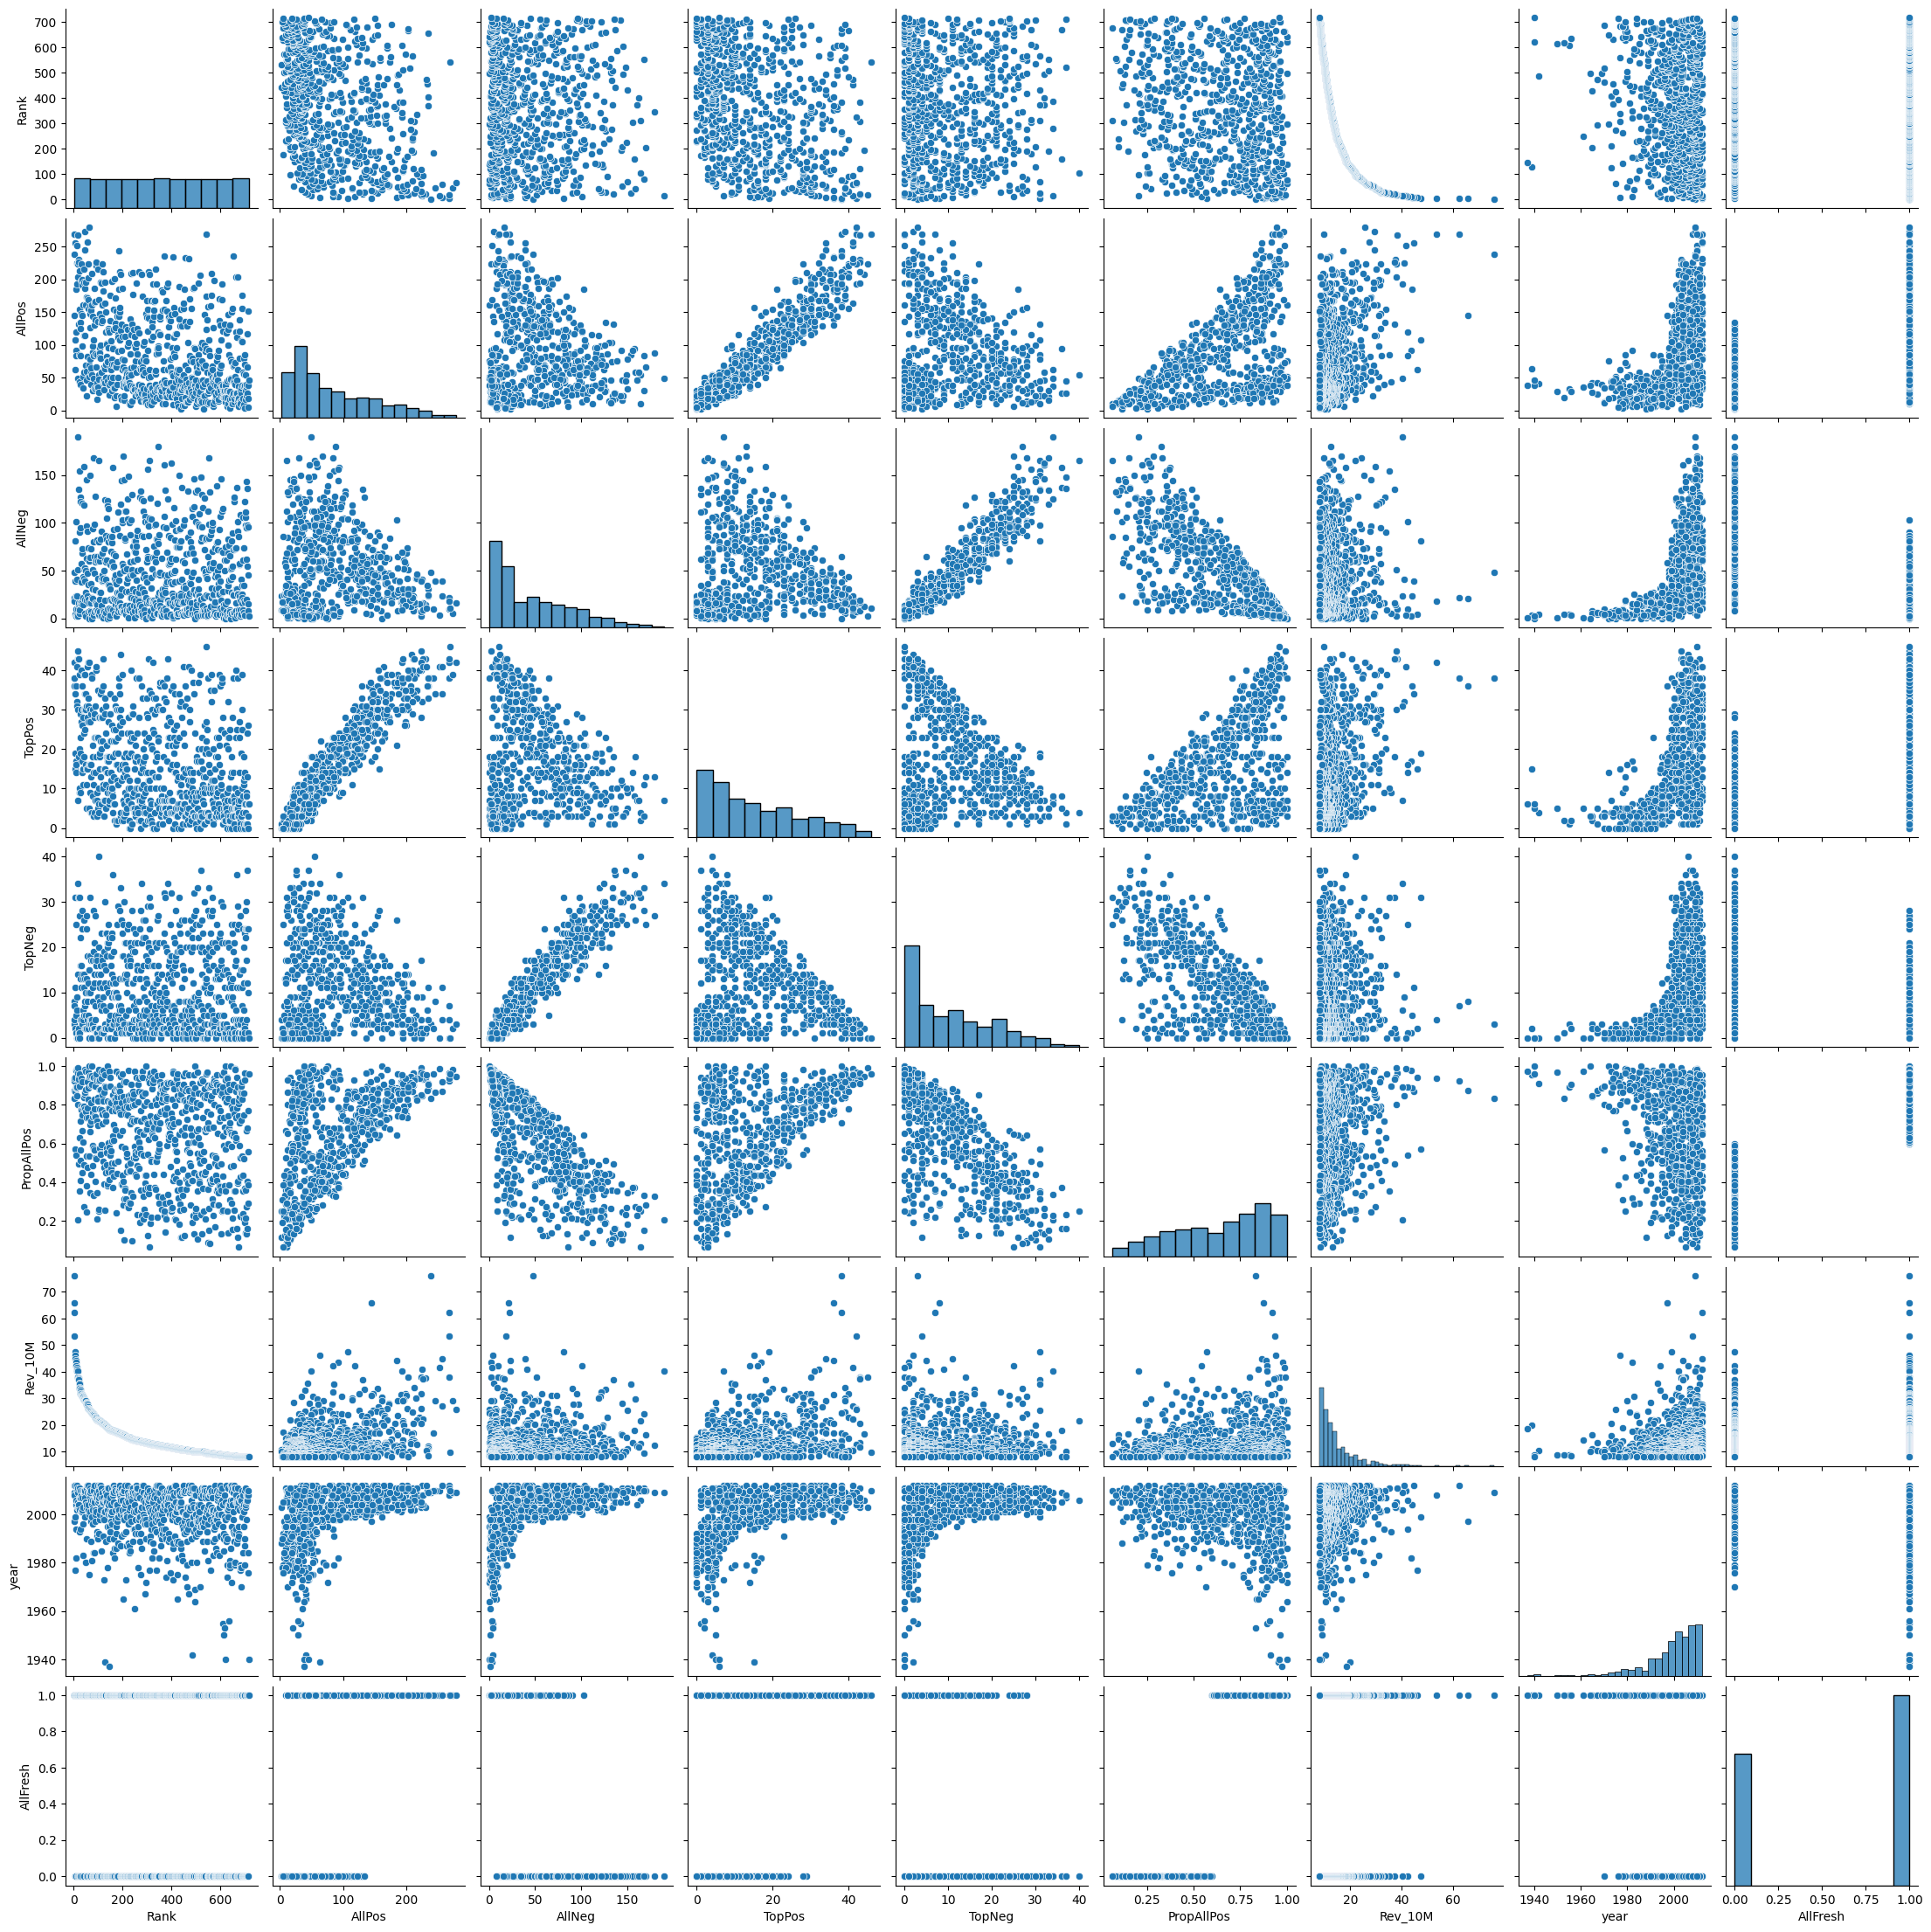

In [ ]:
sns.pairplot(data2)


In [ ]:
model1 = bmb.Model("Rev_10M ~ AllPos + PropAllPos + year + AllFresh", data=data2)
idata1 = model1.fit(tune=2000, draws=2000, cores=1, log_likelihood=True)


In [ ]:
model2 = bmb.Model("Rev_10M ~ bs(AllPos, degree=3, df=4) + PropAllPos + year + AllFresh", data=data2)
idata2 = model2.fit(tune=2000, draws=2000, cores=1, log_likelihood=True)

In [ ]:
print(idata1) # GEMINI DOING SMT TO HELP FIX IDEK WHAT TBH

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data


In [ ]:
model3 = bmb.Model("Rev_10M ~ bs(AllPos, degree=3, df=4) + bs(PropAllPos, degree=2, df=3) + bs(year, degree=2, df=3) + AllFresh", data=data2)
idata3 = model3.fit(tune=2000, draws=2000, cores=1, log_likelihood=True)


In [ ]:
model_dict = {
    'model1': idata1,
    'model2': idata2,
    'model3': idata3
    }

cmp_df_bmb = az.compare(model_dict)
display(cmp_df_bmb)
# just couldn't get this to work

TypeError: Encountered error in ELPD computation of compare.

In [ ]:
az.plot_compare(cmp_df_bmb)
plt.show()